<a href="https://colab.research.google.com/github/danielkini729-arch/Boutique-en-ligne-/blob/main/TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset brut : 85 lignes, 6 colonnes
Dimensions : (85, 6)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mois       85 non-null     object 
 1   marche     85 non-null     object 
 2   produit    85 non-null     object 
 3   prix_fcfa  81 non-null     float64
 4   quantite   81 non-null     float64
 5   total      85 non-null     int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 4.1+ KB

--- VALEURS MANQUANTES ---
mois         0
marche       0
produit      0
prix_fcfa    4
quantite     4
total        0
dtype: int64

--- DOUBLONS ---
Nombre de lignes dupliquées : 5

--- QUANTITÉS = 0 ---
2

--- STATISTIQUES DESCRIPTIVES ---
                mois    marche     produit    prix_fcfa   quantite  \
count             85        85          85    81.000000  81.000000   
unique             3         9           8          NaN        

,prix_fcfa
produit,
Poisson fumé (kg),2912.12
Poulet (kg),2583.61
Huile (1L),1159.19
Arachide (kg),884.14
Plantain (kg),585.71
Riz (1kg),490.44
Igname (kg),416.17
Tomate (kg),262.38


,total
marche,
New-Bell,793081.12
Mfoundi,581917.88
Marché Mvog-Mbi,403057.25
Mokolo,317205.25
Sandaga,195662.00


produit,Arachide (kg),Huile (1L),Igname (kg),Plantain (kg),Poisson fumé (kg),Poulet (kg),Riz (1kg),Tomate (kg)
marche,,,,,,,,
Marché Mvog-Mbi,650.00,NaN,456.00,1625.56,2912.12,2385.00,488.50,249.0
Mfoundi,1772.06,1178.67,438.00,305.67,2912.12,2600.00,507.50,272.0
Mokolo,564.33,1050.00,426.00,325.50,2912.12,2912.12,445.00,228.0
New-Bell,593.00,1209.33,419.33,346.00,2912.12,2601.56,494.25,285.5
Sandaga,NaN,1226.60,380.50,NaN,NaN,NaN,NaN,265.0


,0
produit,
Plantain (kg),1319.89
Arachide (kg),1207.73
Poulet (kg),527.12
Huile (1L),176.60
Igname (kg),75.50
Riz (1kg),62.50
Tomate (kg),57.50
Poisson fumé (kg),0.00


,prix_fcfa
mois,
Janvier 2024,754.71
Février 2024,1398.51
Mars 2024,1405.88


,,ecart_median_pct
marche,produit,
Marché Mvog-Mbi,Plantain (kg),379.52
Mfoundi,Arachide (kg),187.21
Mokolo,Tomate (kg),14.29


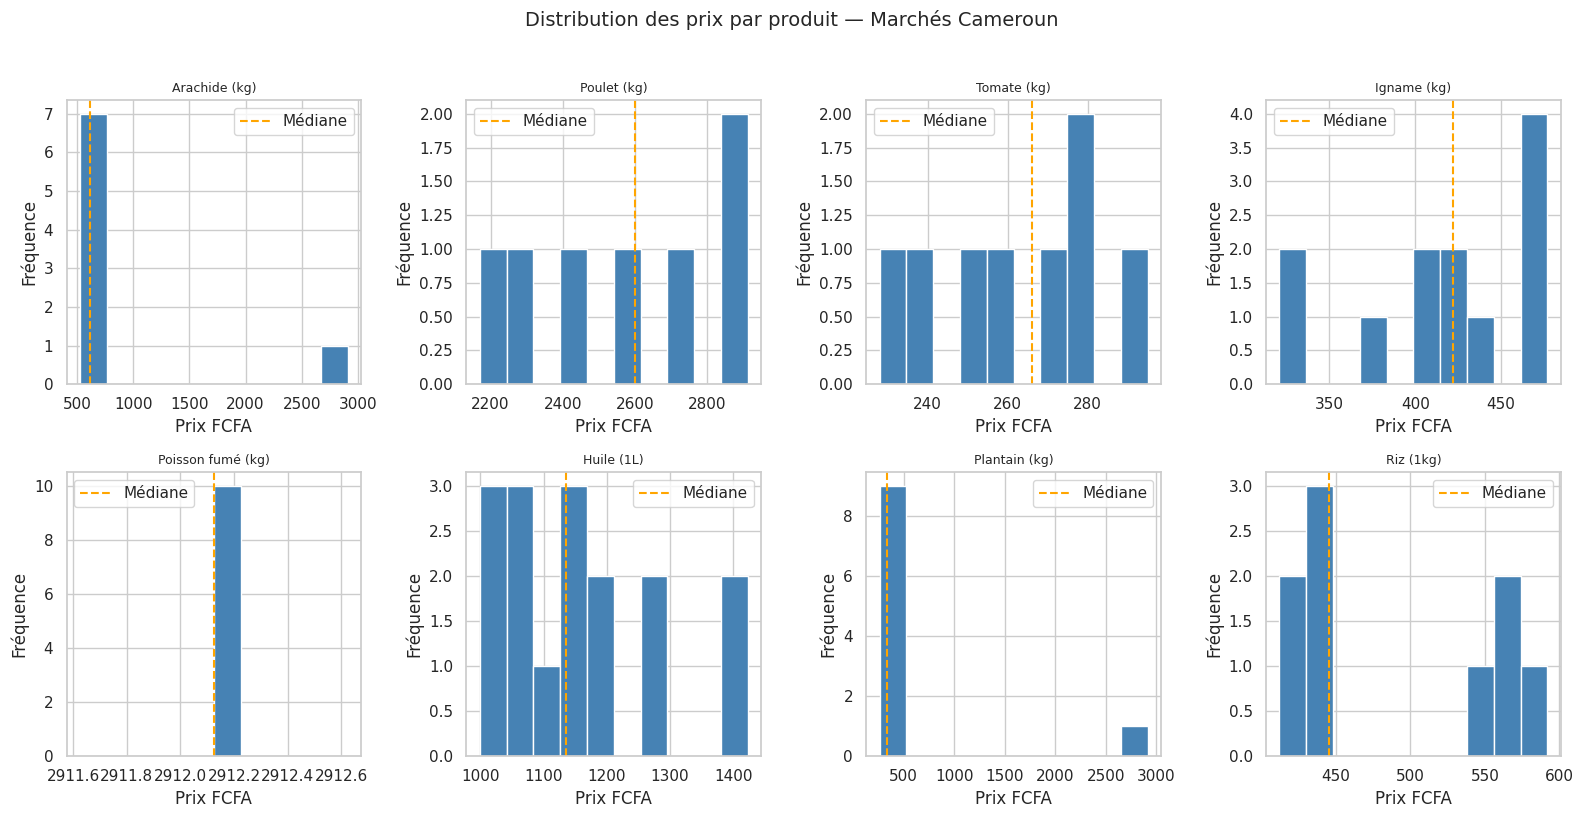

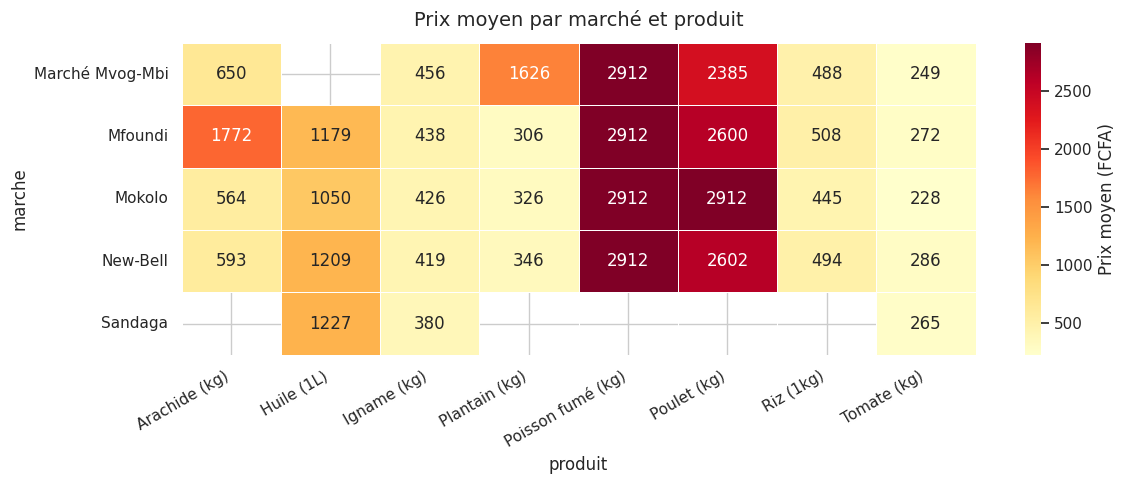

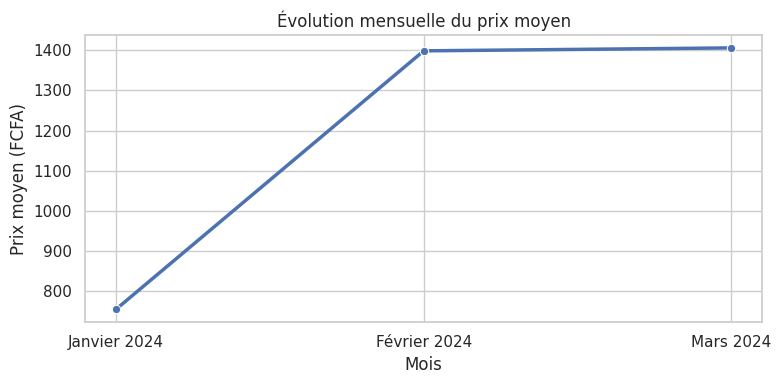

/tmp/ipykernel_1390/82475343.py:265: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ca_marche_plot, x='total', y='marche', palette='viridis')


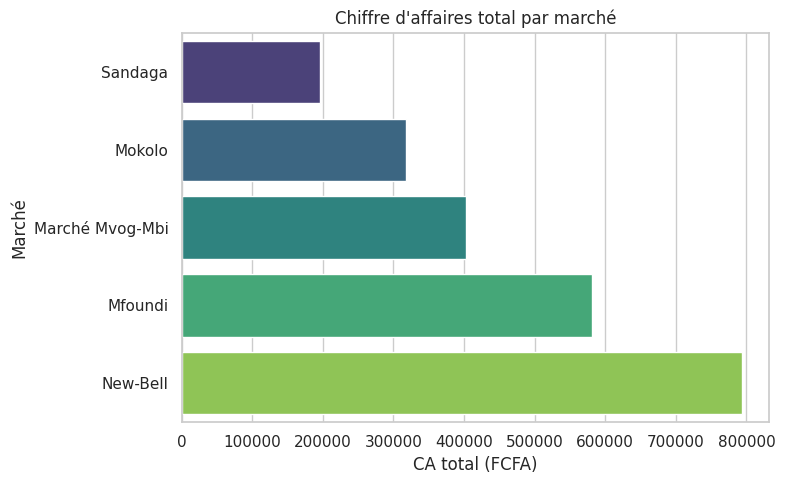

Fichiers exportés avec succès !


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Génération du dataset
n = 80
marches = ['Mokolo','Sandaga','Marché Mvog-Mbi','New-Bell','Mfoundi']
produits = ['Riz (1kg)','Huile (1L)','Tomate (kg)','Plantain (kg)','Poulet (kg)',
            'Igname (kg)','Arachide (kg)','Poisson fumé (kg)']
mois = ['Janvier 2024','Février 2024','Mars 2024']

prix_ref = {
    'Riz (1kg)': 500,
    'Huile (1L)': 1200,
    'Tomate (kg)': 250,
    'Plantain (kg)': 300,
    'Poulet (kg)': 2500,
    'Igname (kg)': 400,
    'Arachide (kg)': 600,
    'Poisson fumé (kg)': 3500
}

data = []

for i in range(n):
    prod = np.random.choice(produits)
    marche = np.random.choice(marches)
    mois_v = np.random.choice(mois)
    prix_b = prix_ref[prod]
    prix = max(50, int(prix_b * np.random.uniform(0.8, 1.2)))
    qty = np.random.randint(1, 50)

    data.append({
        'mois': mois_v,
        'marche': marche,
        'produit': prod,
        'prix_fcfa': prix,
        'quantite': qty,
        'total': prix * qty
    })

df_raw = pd.DataFrame(data)

# Problèmes intentionnels
idx_nan = np.random.choice(df_raw.index, 8, replace=False)
idx_dup = np.random.choice(df_raw.index, 5, replace=False)
idx_out = np.random.choice(df_raw.index, 4, replace=False)

# Valeurs manquantes
df_raw.loc[idx_nan[:4], 'prix_fcfa'] = np.nan
df_raw.loc[idx_nan[4:], 'quantite'] = np.nan

# Doublons
df_raw = pd.concat([df_raw, df_raw.loc[idx_dup]], ignore_index=True)

# Outliers
df_raw.loc[idx_out[:2], 'prix_fcfa'] = df_raw.loc[idx_out[:2], 'prix_fcfa'] * 10
df_raw.loc[idx_out[2:], 'quantite'] = 0

# Casse incohérente
df_raw.loc[df_raw.index[:10], 'marche'] = df_raw.loc[df_raw.index[:10], 'marche'].str.upper()

print(f"Dataset brut : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")
df_raw.head(10)


# Dimensions
print("Dimensions :", df_raw.shape)

# Infos générales
print("\n--- INFO ---")
df_raw.info()

# Valeurs manquantes
print("\n--- VALEURS MANQUANTES ---")
print(df_raw.isnull().sum())

# Doublons
print("\n--- DOUBLONS ---")
print("Nombre de lignes dupliquées :", df_raw.duplicated().sum())

# Quantités égales à 0
print("\n--- QUANTITÉS = 0 ---")
print((df_raw['quantite'] == 0).sum())

# Statistiques descriptives
print("\n--- STATISTIQUES DESCRIPTIVES ---")
print(df_raw.describe(include='all'))


# Étape 3.1 — Copie de sécurité
df = df_raw.copy()
print(f"Avant nettoyage : {df.shape[0]} lignes")

# Étape 3.2 — Standardisation de la colonne marche
df['marche'] = df['marche'].str.title()

print(df['marche'].value_counts())
print("Shape :", df.shape)
print(df.isnull().sum())


# Étape 3.3 — Suppression des doublons
df = df.drop_duplicates()

print(f"Après suppression doublons : {df.shape[0]} lignes")
print(df.isnull().sum())


# Étape 3.4 — Traitement des valeurs manquantes

# D'abord, convertir les quantités nulles en NaN
df.loc[df['quantite'] == 0, 'quantite'] = np.nan

# Imputation de prix_fcfa par la médiane du produit
mediane_prix = df.groupby('produit')['prix_fcfa'].transform('median')
df['prix_fcfa'] = df['prix_fcfa'].fillna(mediane_prix)

# Imputation de quantite par la médiane du produit
mediane_qty = df.groupby('produit')['quantite'].transform('median')
df['quantite'] = df['quantite'].fillna(mediane_qty)

print("NaN restants :", df.isnull().sum().sum())
print(df.shape)
print(df.isnull().sum())


# Étape 3.5 — Détection et traitement des outliers

def corriger_outliers_iqr(serie, nom_col=''):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    n_out = ((serie < borne_inf) | (serie > borne_sup)).sum()
    print(f"{nom_col}: {n_out} outliers → [{borne_inf:.2f}, {borne_sup:.2f}]")

    return serie.clip(lower=borne_inf, upper=borne_sup)

df['prix_fcfa'] = corriger_outliers_iqr(df['prix_fcfa'], 'prix_fcfa')
df['quantite'] = corriger_outliers_iqr(df['quantite'], 'quantite')

# Recalcul du total
df['total'] = df['prix_fcfa'] * df['quantite']

print(f"Après nettoyage complet : {df.shape[0]} lignes, {df.isnull().sum().sum()} NaN")


# Étape 3.6 — Ajouter des colonnes utiles

mediane_ref = df.groupby('produit')['prix_fcfa'].transform('median')

df['ecart_median_pct'] = (df['prix_fcfa'] - mediane_ref) / mediane_ref * 100

df['tranche_prix'] = pd.cut(
    df['prix_fcfa'],
    bins=[0, 300, 600, 1500, float('inf')],
    labels=['Bas', 'Moyen', 'Élevé', 'Premium']
)

print(df[['produit', 'prix_fcfa', 'ecart_median_pct', 'tranche_prix']].head(10))


prix_moyen = df.groupby('produit')['prix_fcfa'].mean().sort_values(ascending=False).round(2)
display(prix_moyen)


ca_marche = df.groupby('marche')['total'].sum().sort_values(ascending=False).round(2)
display(ca_marche)


pivot_prix = df.pivot_table(
    values='prix_fcfa',
    index='marche',
    columns='produit',
    aggfunc='mean'
).round(2)

display(pivot_prix)

variation_prix = (pivot_prix.max(axis=0) - pivot_prix.min(axis=0)).sort_values(ascending=False).round(2)
display(variation_prix)


ordre_mois = ['Janvier 2024', 'Février 2024', 'Mars 2024']
df['mois'] = pd.Categorical(df['mois'], categories=ordre_mois, ordered=True)

prix_mensuels = df.groupby('mois', observed=False)['prix_fcfa'].mean().round(2)
display(prix_mensuels)


top3_ecarts = (
    df.groupby(['marche', 'produit'])['ecart_median_pct']
      .mean()
      .abs()
      .sort_values(ascending=False)
      .head(3)
      .round(2)
)

display(top3_ecarts)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
produits_liste = df['produit'].unique()

for i, prod in enumerate(produits_liste):
    ax = axes[i // 4, i % 4]
    data_prod = df[df['produit'] == prod]['prix_fcfa']

    ax.hist(data_prod, bins=10, color='steelblue', edgecolor='white')
    ax.axvline(data_prod.median(), color='orange', linestyle='--', label='Médiane')
    ax.set_title(prod, fontsize=9)
    ax.set_xlabel('Prix FCFA')
    ax.set_ylabel('Fréquence')
    ax.legend()

plt.suptitle('Distribution des prix par produit — Marchés Cameroun', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


pivot_viz = df.pivot_table(
    values='prix_fcfa',
    index='marche',
    columns='produit',
    aggfunc='mean'
)

plt.figure(figsize=(12, 5))
sns.heatmap(
    pivot_viz,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Prix moyen (FCFA)'}
)
plt.title('Prix moyen par marché et produit', fontsize=14, pad=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


prix_mensuels_plot = df.groupby('mois', observed=False)['prix_fcfa'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=prix_mensuels_plot, x='mois', y='prix_fcfa', marker='o', linewidth=2.5)
plt.title("Évolution mensuelle du prix moyen")
plt.xlabel("Mois")
plt.ylabel("Prix moyen (FCFA)")
plt.tight_layout()
plt.show()


ca_marche_plot = df.groupby('marche')['total'].sum().sort_values().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=ca_marche_plot, x='total', y='marche', palette='viridis')
plt.title("Chiffre d'affaires total par marché")
plt.xlabel("CA total (FCFA)")
plt.ylabel("Marché")
plt.tight_layout()
plt.show()


# Export CSV
df.to_csv('marches_cameroun_propre.csv', index=False, encoding='utf-8')

# Export Excel
with pd.ExcelWriter('marches_cameroun_propre.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Données_nettoyées', index=False)

    stats_resume = (
        df.groupby('produit')
          .agg(
              prix_moyen=('prix_fcfa', 'mean'),
              prix_median=('prix_fcfa', 'median'),
              qty_totale=('quantite', 'sum'),
              ca_total=('total', 'sum')
          )
          .round(0)
          .reset_index()
    )

    stats_resume.to_excel(writer, sheet_name='Statistiques', index=False)

print("Fichiers exportés avec succès !")

